# REGRESSION TEST 

In [1]:
# os
import os, sys, random

# visualization
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# ml
import numpy as np
import torchvision as tv
import torch
from PIL import Image
from sklearn.model_selection import train_test_split

# data aug
import copy
import shutil
from collections import defaultdict
from urllib.request import urlretrieve

# helpers
import dataloader as dl
from pathlib import Path
import helpers as help

sys.path.append('../streaming_base')#
#from streaming_base.processing.processing import beamform_2d
from streaming_base.utils.utils import get_ant_pos_2d, plot_2d_polar_heatmap, plot_2d_heatmap
from utils.utility import read_radar_params

%load_ext autoreload
%autoreload 2

In [2]:
# defs
home_dir = "D:/GitHub/COM-304-Rat-Detection"
data_dir = "data/ml"

json_filename = r"scripts/chirp1"
config_lua_script = r'scripts/1843_config_streaming_task3.lua' 

In [3]:
args, chirp_dict = dl.read_lua_config(home_dir, config_lua_script)

In [4]:
names, raw_data, fft_data = help.load_data(data_dir, home_dir, json_filename, args)
virtual_ant_dict = help.make_virtual_ant_dict(raw_data, names)

In [5]:
print(virtual_ant_dict['pipe_take8'].shape)

(20, 12, 128)


In [6]:
# label data
labeled_data = {}
no_jerry_keys = ["lhs", "rhs", "left", "right"]

for name, raw_data in virtual_ant_dict.items():
    if (("jerry" in name.lower()) and 
        not any(key in name.lower() for key in no_jerry_keys)):
        label = 1  
    else:
        label = 0 
    labeled_data[name] = {
        "data": raw_data,
        "label": label
    }
    
print("Labeled data dict keys: ", labeled_data.keys())
print("Labels assigned: ")
for name in labeled_data:
    print(f"{name}: {labeled_data[name]['label']}")
    print(f"Data shape for {name}: {labeled_data[name]['data'].shape}")

Labeled data dict keys:  dict_keys(['highres_rat_setup-piped-jerry-antenna-aligned_take-3_fs-2420_slp-62-474_N-128', 'highres_rat_setup-piped-jerry_take-1_fs-2420_slp-62-474_N-128', 'highres_rat_setup-piped-jerry_take-2_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-1_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-2_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-3_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-4_fs-2420_slp-62-474_N-128', 'highres_rat_setup-pipe_take-5_fs-2420_slp-62-474_N-128', 'jerry_no-pipe_aligned1', 'jerry_no-pipe_aligned2', 'jerry_no-pipe_aligned3', 'jerry_no-pipe_aligned4', 'jerry_no-pipe_aligned5', 'jerry_no-pipe_aligned', 'jerry_no-pipe_lhs1', 'jerry_no-pipe_lhs2', 'jerry_no-pipe_lhs3', 'jerry_no-pipe_lhs4', 'jerry_no-pipe_lhs5', 'jerry_no-pipe_rhs1', 'jerry_no-pipe_rhs2', 'jerry_no-pipe_rhs3', 'jerry_no-pipe_rhs4', 'jerry_no-pipe_rhs5', 'jerry_no-pipe_wall_aligned1', 'jerry_no-pipe_wall_aligned2', 'jerry_no-pipe_wall_aligne

In [7]:
# data exploration
print(f"Total samples: {len(labeled_data)}")

label_counts = defaultdict(int)
for item in labeled_data.values():
    label_counts[item['label']] += 1
print(f"Class distribution: {label_counts}")

Total samples: 149
Class distribution: defaultdict(<class 'int'>, {1: 54, 0: 95})


In [8]:
# prep for beamform
num_rx = chirp_dict['num_rx'] 
num_tx = chirp_dict['num_tx']
num_chirps = args[2] # not sure chirp dict equiv
num_loops = chirp_dict['chirp_loops']
adc_samples = chirp_dict['samples_per_chirp']

num_virtual_ant = num_rx * num_tx
samples_per_frame = num_virtual_ant * num_chirps * num_loops  # num_virtual_ant * samples_per_chirp * chirp_loop


#r_idxs = np.arange(0, chirp_dict['samples_per_chirp'], 1)
_max_bin = max(8, int(1.5 / chirp_dict['range_res']))
r_idxs = np.arange(0, min(_max_bin, chirp_dict['samples_per_chirp']), 1)

# r_idxs = np.arange(0, 64, 1)

phi = np.deg2rad(np.arange(0, 180, 1))
width =  len(r_idxs) ## 100 # 100 # azimuth width in degrees

cfg_radar = {
        "range_idx": r_idxs,
        "phi": phi,
        "width": width,
        "n_radar": 1,
        "num_tx": chirp_dict['num_tx'],
        "num_rx": chirp_dict['num_rx'],
        "num_doppler": chirp_dict['chirp_loops'],
        "samples_per_chirp": chirp_dict['samples_per_chirp'],
        "sample_rate": chirp_dict['sample_rate'],
        "c": 3e8,
        "lm": 3e8 / 77e9,
        "slope": chirp_dict['slope'],
        "range_res": chirp_dict['range_res'],           # NOTE : I ADDED THIS -- 4/20/2026 - KERIM
}


print(args)
print("Number of virtual antennas: ", num_virtual_ant)
print("Samples per frame: ", samples_per_frame)


[3, 4, 128, 1, '0x7', '0xF']
Number of virtual antennas:  12
Samples per frame:  1536


In [9]:
#r_idxs = cfg_radar["range_idx"]
num_tx = cfg_radar["num_tx"]
num_rx = cfg_radar["num_rx"]
chirp_loops = cfg_radar["num_doppler"]
adc_samples = cfg_radar["samples_per_chirp"]
x_locs, _, _ = get_ant_pos_2d(num_tx * num_rx, adc_samples, num_rx)

last_frame = np.zeros((num_rx * num_tx, chirp_loops, adc_samples), dtype=np.complex64)
last_frames = np.zeros((5, num_rx * num_tx, chirp_loops, adc_samples), dtype=np.complex64)

In [10]:
X, y = [], []
for name in labeled_data:
    data = labeled_data[name]['data']  # (frames, ants, range)
    label = labeled_data[name]['label']

    adc_windowed = data * np.hamming(adc_samples)

    # Reshape the data to (num_tx*num_rx, chirp_loops, adc_samples)
    #adc_windowed = adc_windowed.reshape(chirp_loops, num_tx, num_rx, adc_samples)
    #adc_windowed = adc_windowed.transpose(1, 2, 0, 3) # tx, rx, loops, adc samples
    #adc_windowed = adc_windowed.reshape(num_tx*num_rx, chirp_loops, adc_samples)

    # Apply FFT along the range dimension
    range_fft = np.fft.fft(adc_windowed, axis=-1) 
    last_frame_fft = np.fft.fft(last_frame, axis=-1)   

    # Update the last frame
    last_frame = adc_windowed

    range_fft_s = range_fft[:, :, r_idxs]

    # Set the static range indices to zero
    range_fft_s[:, :, 0:4] = 0 

    # append current frame
    last_frames[:-1] = last_frames[1:]
    #last_frames[-1] = range_fft_s

    #for frame in data:
    #bf_input = np.mean(last_frames, axis=0)  # (ants, range)
    bf_input = np.mean(range_fft_s, axis=0)


    bf_output = help.beamform_2d( # same as other
        bf_input.squeeze(),
        cfg_radar,
        x_locs[:, 0],
    )
    max_output = abs(bf_output).max()

    bf_output /= max_output
    bf_output = abs(bf_output)

    # normalise
    #img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    X.append(bf_output) #img
    y.append(label)

In [11]:
X = np.array(np.copy(X))       # appears ads shape (N, 180, 40)
y = np.array(np.copy(y)) 

X = X[:, None, :, :]   # (200, 1, 180, 40)
print("Final dataset shapes - X: ", X.shape, ", y: ", y.shape)
print(X.min(), X.max(), X.mean())

Final dataset shapes - X:  (149, 1, 180, 33) , y:  (149,)
0.0 1.0 0.02888089


In [12]:
# flatten for regression
X = X.reshape(X.shape[0], -1) 
print("After flattening, X shape: ", X.shape)

After flattening, X shape:  (149, 5940)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shapes - X: ", X_train.shape, ", y: ", y_train.shape)
print("Test shapes - X: ", X_test.shape, ", y: ", y_test.shape)

Train shapes - X:  (111, 5940) , y:  (111,)
Test shapes - X:  (38, 5940) , y:  (38,)


In [14]:
# model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        24
           1       0.75      0.86      0.80        14

    accuracy                           0.84        38
   macro avg       0.83      0.85      0.83        38
weighted avg       0.85      0.84      0.84        38



In [15]:
# save model
import joblib

joblib.dump(model, "model/jerry_detector_doppler.joblib")

['model/jerry_detector_doppler.joblib']

In [16]:
# test incase of a leak
y_train_shuffled = np.random.permutation(y_train)

model.fit(X_train, y_train_shuffled)

print(model.score(X_test, y_test))

0.6578947368421053


# Heres what we get:
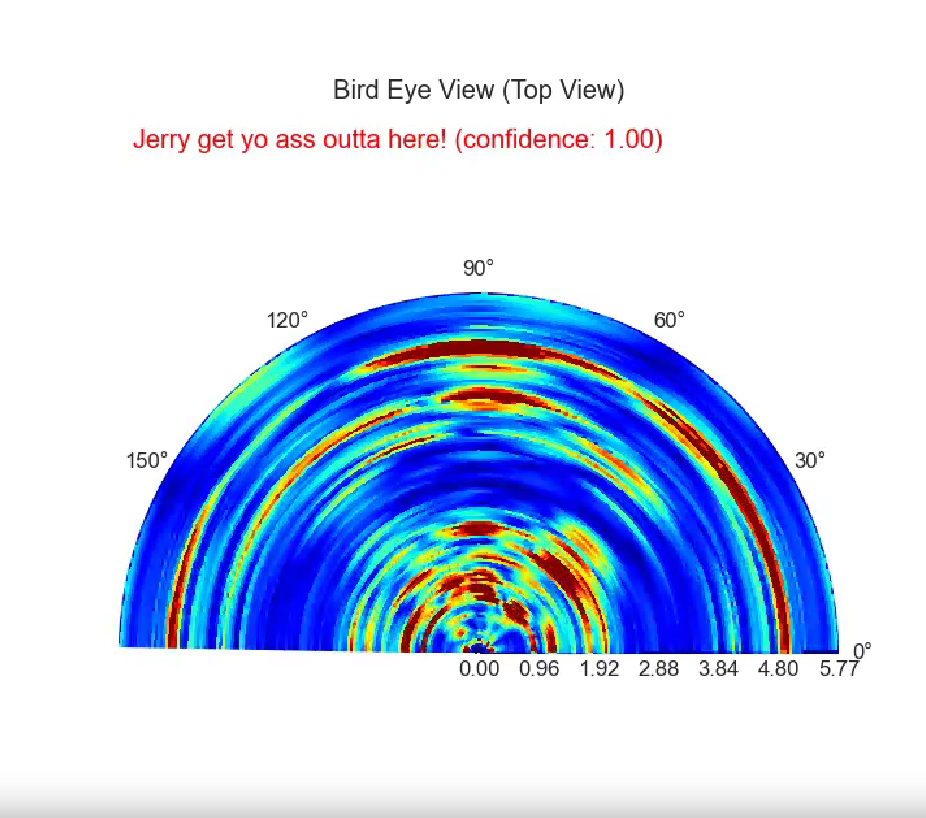
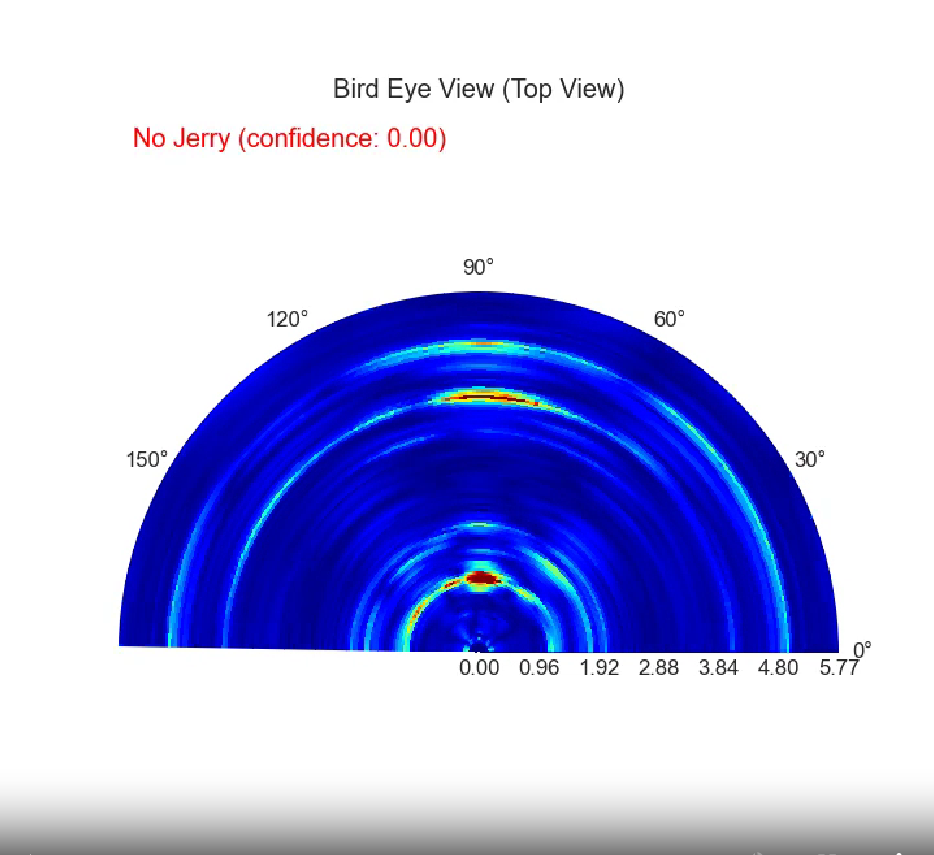